# Sprint 5 – Result Analysis: Baseline (03) vs BERT (04 vs 05)

Perbandingan menyeluruh tiga generasi model:

| Task | Notebook 03 (baseline) | Notebook 04 | Notebook 05 |
|---|---|---|---|
| NER  | `ner_crf_baseline` (CRF + hand-crafted features) | `ner_bert_final` (bert-base-cased, batch 16, max_len 64) | `ner_bert_base_cased` (bert-base-cased, batch 32, fp16, max_len 128) |
| ABSA | `absa_tfidf_svm_baseline` (TF-IDF + LinearSVC) | `absa_finbert_final` (ProsusAI/finbert **+ class weights**) | `absa_bert_base_uncased` (bert-base-uncased, **tanpa weights**) |

**Aspek yang dibandingkan:**
1. Ukuran model (disk, parameter, vocab)
2. Performa NER (entity-level F1)
3. Performa ABSA (macro-F1, per-class, confusion matrix)
4. Robustness multi-conflict (metrik kunci proyek)
5. Kecepatan inferensi
6. Agreement & kalibrasi confidence (khusus 04 vs 05 — SVM tidak punya probabilitas)

Semua model dievaluasi pada **test set yang sama** sehingga perbandingannya apple-to-apple.
Baseline disertakan untuk menunjukkan **trade-off ukuran/kecepatan vs akurasi**: CRF+SVM
±3 MB dan jalan kencang di CPU; BERT ±420 MB butuh GPU — apakah kenaikan akurasinya sepadan?

In [42]:
import json, time
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (classification_report, f1_score, confusion_matrix,
                             precision_recall_fscore_support)
from seqeval.metrics import classification_report as seq_report, f1_score as seq_f1
from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                          AutoModelForSequenceClassification)

DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'
PROJECT_ROOT   = Path('/home/anton/TextMining/Financial-News-Miner')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR      = PROJECT_ROOT / 'backend' / 'models'

NER_LABELS = ['O', 'B-ENT', 'I-ENT']
ABSA_NAMES = ['negative', 'neutral', 'positive']
print('Device:', DEVICE)

Device: cuda


In [43]:
import joblib

MODEL_PATHS = {
    'NER-03 (CRF)':           MODEL_DIR / 'ner_crf_baseline.joblib',
    'NER-04 (bert-cased)':    MODEL_DIR / 'ner_bert_final',
    'NER-05 (bert-cased)':    MODEL_DIR / 'ner_bert_base_cased',
    'ABSA-03 (TFIDF+SVM)':    MODEL_DIR / 'absa_tfidf_svm_baseline.joblib',
    'ABSA-04 (FinBERT+w)':    MODEL_DIR / 'absa_finbert_final',
    'ABSA-05 (BERT-uncased)': MODEL_DIR / 'absa_bert_base_uncased',
}

# Baseline (Sprint 3)
crf = joblib.load(MODEL_PATHS['NER-03 (CRF)'])
svm_bundle = joblib.load(MODEL_PATHS['ABSA-03 (TFIDF+SVM)'])
vectorizer, svm = svm_bundle['vectorizer'], svm_bundle['svm']

# Transformer (Sprint 4)
ner04_tok = AutoTokenizer.from_pretrained(MODEL_PATHS['NER-04 (bert-cased)'])
ner04     = AutoModelForTokenClassification.from_pretrained(
    MODEL_PATHS['NER-04 (bert-cased)']).to(DEVICE).eval()
ner05_tok = AutoTokenizer.from_pretrained(MODEL_PATHS['NER-05 (bert-cased)'])
ner05     = AutoModelForTokenClassification.from_pretrained(
    MODEL_PATHS['NER-05 (bert-cased)']).to(DEVICE).eval()

absa04_tok = AutoTokenizer.from_pretrained(MODEL_PATHS['ABSA-04 (FinBERT+w)'])
absa04     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATHS['ABSA-04 (FinBERT+w)']).to(DEVICE).eval()
absa05_tok = AutoTokenizer.from_pretrained(MODEL_PATHS['ABSA-05 (BERT-uncased)'])
absa05     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATHS['ABSA-05 (BERT-uncased)']).to(DEVICE).eval()

print('6 model loaded (2 baseline + 4 transformer)')

/home/anton/TextMining/.venv/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/anton/TextMining/.venv/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/anton/TextMining/.venv/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.8.0 when using

6 model loaded (2 baseline + 4 transformer)


## 1. Ukuran Model

Ukuran disk dihitung dari total file di folder model (bukan `stat()` direktorinya).  
Perbedaan vocab: `bert-base-cased` 28.996 token, `bert-base-uncased`/FinBERT 30.522 token —  
FinBERT memakai vocab BERT-uncased karena di-pre-train ulang dari checkpoint itu.

In [44]:
def dir_size_mb(p: Path) -> float:
    if p.is_file():
        return round(p.stat().st_size / 1e6, 1)
    return round(sum(f.stat().st_size for f in p.rglob('*') if f.is_file()) / 1e6, 1)

def n_params_m(model) -> float:
    return round(sum(p.numel() for p in model.parameters()) / 1e6, 1)

rows = [
    # Baseline: "parameter" = jumlah bobot yang dipelajari
    {'model': 'NER-03 (CRF)',
     'disk_MB': dir_size_mb(MODEL_PATHS['NER-03 (CRF)']),
     'params_M': round((len(crf.state_features_) + len(crf.transition_features_)) / 1e6, 3),
     'vocab_size': '-', 'device': 'CPU'},
    {'model': 'ABSA-03 (TFIDF+SVM)',
     'disk_MB': dir_size_mb(MODEL_PATHS['ABSA-03 (TFIDF+SVM)']),
     'params_M': round(svm.coef_.size / 1e6, 3),
     'vocab_size': len(vectorizer.vocabulary_), 'device': 'CPU'},
]
for name, model, tok in [
    ('NER-04 (bert-cased)',    ner04,  ner04_tok),
    ('NER-05 (bert-cased)',    ner05,  ner05_tok),
    ('ABSA-04 (FinBERT+w)',    absa04, absa04_tok),
    ('ABSA-05 (BERT-uncased)', absa05, absa05_tok),
]:
    rows.append({'model': name,
                 'disk_MB': dir_size_mb(MODEL_PATHS[name]),
                 'params_M': n_params_m(model),
                 'vocab_size': tok.vocab_size,
                 'device': DEVICE.upper()})

size_df = pd.DataFrame(rows).set_index('model')
print(size_df.to_string())
print(f"\nRasio ukuran: BERT ~{size_df.loc['ABSA-04 (FinBERT+w)','disk_MB'] / size_df.loc['ABSA-03 (TFIDF+SVM)','disk_MB']:.0f}× lebih besar dari baseline SVM")

                        disk_MB  params_M vocab_size device
model                                                      
NER-03 (CRF)                1.6     0.027          -    CPU
ABSA-03 (TFIDF+SVM)         1.3     0.081      27051    CPU
NER-04 (bert-cased)       431.6   107.700      28996   CUDA
NER-05 (bert-cased)       431.6   107.700      28996   CUDA
ABSA-04 (FinBERT+w)       438.7   109.500      30522   CUDA
ABSA-05 (BERT-uncased)    438.7   109.500      30522   CUDA

Rasio ukuran: BERT ~337× lebih besar dari baseline SVM


## 2. Performa NER

Tiga model dievaluasi entity-level (seqeval): satu entitas multi-token dihitung benar
hanya jika seluruh span tepat.

- CRF (03): hand-crafted features (bentuk kata, prefix/suffix, konteks ±2) — di-rekonstruksi
  identik dengan notebook 03 agar joblib bisa dipakai.
- BERT CASED

In [45]:
def load_ner_jsonl(path):
    sents, labels = [], []
    with open(path, encoding='utf-8') as f:
        for line in f:
            d = json.loads(line)
            sents.append(d['tokens']); labels.append(d['ner_tags'])
    return sents, labels

test_sents, test_labels = load_ner_jsonl(DATA_PROCESSED / 'ner_test.jsonl')

def word2features(sent, i):
    w = sent[i]
    f = {'bias': 1.0, 'w.lower': w.lower(), 'w.suffix3': w[-3:], 'w.suffix2': w[-2:],
         'w.prefix2': w[:2], 'w.isupper': w.isupper(), 'w.istitle': w.istitle(),
         'w.isdigit': w.isdigit(), 'w.hasdigit': any(c.isdigit() for c in w),
         'w.hashyphen': '-' in w, 'w.len': len(w)}
    if i > 0:
        p = sent[i-1]
        f.update({'-1.lower': p.lower(), '-1.istitle': p.istitle(), '-1.isupper': p.isupper()})
    else:
        f['BOS'] = True
    if i > 1:
        p = sent[i-2]
        f.update({'-2.lower': p.lower(), '-2.istitle': p.istitle()})
    if i < len(sent) - 1:
        n = sent[i+1]
        f.update({'+1.lower': n.lower(), '+1.istitle': n.istitle(), '+1.isupper': n.isupper()})
    else:
        f['EOS'] = True
    if i < len(sent) - 2:
        n = sent[i+2]
        f.update({'+2.lower': n.lower(), '+2.istitle': n.istitle()})
    return f

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

# --- BERT inference ---
def predict_ner(model, tokenizer, sentences, max_length=128):
    preds = []
    for sent in sentences:
        enc = tokenizer(sent, is_split_into_words=True, return_tensors='pt',
                        truncation=True, max_length=max_length).to(DEVICE)
        with torch.no_grad():
            ids = model(**enc).logits[0].argmax(-1).cpu().tolist()
        word_ids = enc.word_ids(batch_index=0)
        wp = {}
        for ti, wid in enumerate(word_ids):
            if wid is not None and wid not in wp:
                wp[wid] = NER_LABELS[ids[ti]]
        preds.append([wp[w] for w in sorted(wp)])
    return preds

ner_pred_crf = crf.predict([sent2features(s) for s in test_sents])
ner_pred_04  = predict_ner(ner04, ner04_tok, test_sents)

ner_f1_crf = seq_f1(test_labels, ner_pred_crf)
ner_f1_04  = seq_f1(test_labels, ner_pred_04)
print(f'\nNER-CRF  entity-F1: {ner_f1_crf:.4f}')
print(f'NER-BERT-CASED BERT entity-F1: {ner_f1_04:.4f}  ({ner_f1_04 - ner_f1_crf:+.4f} vs CRF)')



NER-CRF  entity-F1: 0.8374
NER-BERT-CASED BERT entity-F1: 0.9148  (+0.0774 vs CRF)


In [46]:
# Di headline mana kedua model NER tidak sepakat?
n_disagree = 0
shown = 0
for sent, gold, p4, p5 in zip(test_sents, test_labels, ner_pred_04, ner_pred_05):
    if p4 != p5:
        n_disagree += 1
        if shown < 5:
            print('TOKENS:', ' '.join(sent))
            for tok, g, a, b in zip(sent, gold, p4, p5):
                if a != b:
                    win = '04' if a == g else ('05' if b == g else '–')
                    print(f'   {tok:20s} gold={g:6s} 04={a:6s} 05={b:6s} benar: {win}')
            print()
            shown += 1

print(f'Total headline dengan prediksi berbeda: {n_disagree}/{len(test_sents)}',
      f'({n_disagree/len(test_sents):.1%})')

TOKENS: Billionaire's stake shakes Woolworth's buyout of David Jones
   Billionaire's        gold=O      04=O      05=B-ENT  benar: 04

TOKENS: Is this a good time to purchase gold jewellery?
   jewellery?           gold=O      04=O      05=I-ENT  benar: 04

TOKENS: Domestic companies turn back on bank loans, issue bonds instead
   bank                 gold=O      04=B-ENT  05=O      benar: 05

TOKENS: SAT clubs KP Singh, other petitions with main DLF case
   DLF                  gold=B-ENT  04=B-ENT  05=O      benar: 04

TOKENS: Anil Ambani-led Reliance Infrastructure appoints ex-Vedanta chief, MS Mehta, as CEO
   ex-Vedanta           gold=O      04=B-ENT  05=O      benar: 05

Total headline dengan prediksi berbeda: 81/1060 (7.6%)


## 3. Performa ABSA

Inferensi batch kedua model pada test set yang sama (1.448 pasangan title-entity).

In [47]:
absa_test = pd.read_csv(DATA_PROCESSED / 'absa_test.csv')
y_true = absa_test['label'].to_numpy()

# SVM: input = title [SEP] entity (identik dengan notebook 03)
text_test = absa_test['title'] + ' [SEP] ' + absa_test['entity']
y_svm = svm.predict(vectorizer.transform(text_test))

# BERT: batch inference
def absa_probs(model, tokenizer, df, batch_size=64, max_length=128):
    probs = []
    for i in range(0, len(df), batch_size):
        chunk = df.iloc[i:i + batch_size]
        enc = tokenizer(chunk['title'].tolist(), chunk['entity'].tolist(),
                        return_tensors='pt', truncation=True,
                        max_length=max_length, padding=True).to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
        probs.append(torch.softmax(logits, -1).cpu().numpy())
    return np.vstack(probs)

probs_04 = absa_probs(absa04, absa04_tok, absa_test)
probs_05 = absa_probs(absa05, absa05_tok, absa_test)

y_04 = probs_04.argmax(1)
y_05 = probs_05.argmax(1)

print('\n ABSA-03 TF-IDF + LinearSVC (baseline) ')
print(classification_report(y_true, y_svm, target_names=ABSA_NAMES, digits=4))
print(' ABSA-04 FinBERT + class weights ')
print(classification_report(y_true, y_04, target_names=ABSA_NAMES, digits=4))
print(' ABSA-05 BERT-uncased (no weights) ')
print(classification_report(y_true, y_05, target_names=ABSA_NAMES, digits=4))


 ABSA-03 TF-IDF + LinearSVC (baseline) 
              precision    recall  f1-score   support

    negative     0.7686    0.7266    0.7470       384
     neutral     0.7744    0.7956    0.7849       548
    positive     0.7644    0.7733    0.7688       516

    accuracy                         0.7693      1448
   macro avg     0.7691    0.7651    0.7669      1448
weighted avg     0.7693    0.7693    0.7691      1448

 ABSA-04 FinBERT + class weights 
              precision    recall  f1-score   support

    negative     0.8903    0.8880    0.8892       384
     neutral     0.8302    0.8923    0.8602       548
    positive     0.9223    0.8508    0.8851       516

    accuracy                         0.8764      1448
   macro avg     0.8809    0.8770    0.8781      1448
weighted avg     0.8790    0.8764    0.8767      1448

 ABSA-05 BERT-uncased (no weights) 
              precision    recall  f1-score   support

    negative     0.8848    0.8802    0.8825       384
     neutral     0

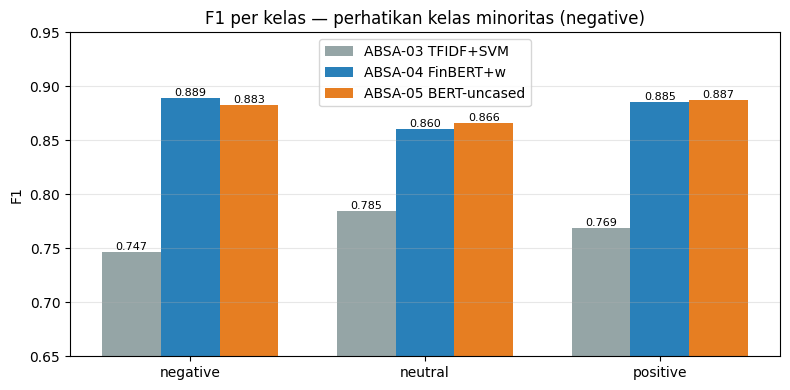

Macro-F1 ABSA-03 (SVM)  : 0.7669
Macro-F1 ABSA-04 (04)   : 0.8781
Macro-F1 ABSA-05 (05)   : 0.8785


In [48]:
_, _, f1_svm, _ = precision_recall_fscore_support(y_true, y_svm)
_, _, f1_04,  _ = precision_recall_fscore_support(y_true, y_04)
_, _, f1_05,  _ = precision_recall_fscore_support(y_true, y_05)

x, w = np.arange(3), 0.25
fig, ax = plt.subplots(figsize=(8, 4))
b0 = ax.bar(x - w, f1_svm, w, label='ABSA-03 TFIDF+SVM', color='#95a5a6')
b1 = ax.bar(x,     f1_04,  w, label='ABSA-04 FinBERT+w', color='#2980b9')
b2 = ax.bar(x + w, f1_05,  w, label='ABSA-05 BERT-uncased', color='#e67e22')
for b in (b0, b1, b2):
    ax.bar_label(b, fmt='%.3f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(ABSA_NAMES)
ax.set_ylabel('F1'); ax.set_ylim(0.65, 0.95)
ax.set_title('F1 per kelas — perhatikan kelas minoritas (negative)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Macro-F1 ABSA-03 (SVM)  : {f1_score(y_true, y_svm, average="macro"):.4f}')
print(f'Macro-F1 ABSA-04 (04)   : {f1_score(y_true, y_04, average="macro"):.4f}')
print(f'Macro-F1 ABSA-05 (05)   : {f1_score(y_true, y_05, average="macro"):.4f}')

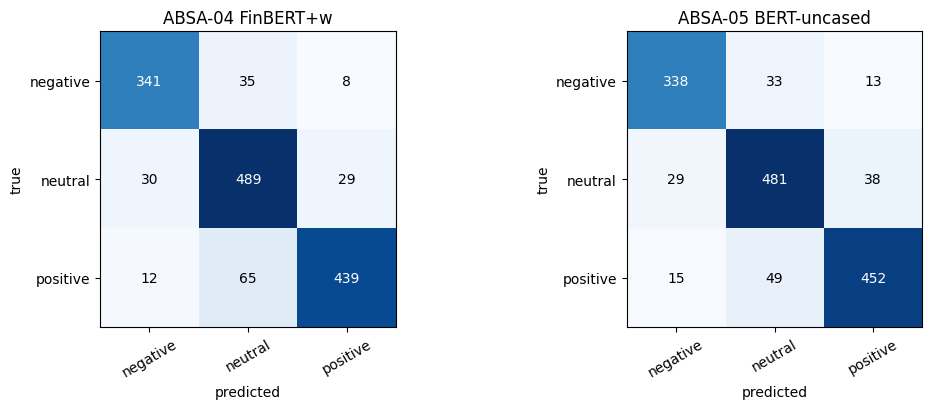

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (name, yp) in zip(axes, [('ABSA-04 FinBERT+w', y_04),
                                  ('ABSA-05 BERT-uncased', y_05)]):
    cm = confusion_matrix(y_true, yp)
    ax.imshow(cm, cmap='Blues')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_xticks(range(3)); ax.set_xticklabels(ABSA_NAMES, rotation=30)
    ax.set_yticks(range(3)); ax.set_yticklabels(ABSA_NAMES)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(name)
plt.tight_layout(); plt.show()

## 4. Robustness Multi-Conflict (Metrik Kunci)

Gap akurasi single vs multi-conflict adalah ukuran seberapa *aspect-aware* model.  
Baseline BoW Sprint 3 punya gap 0.2057 — semakin kecil semakin baik.

                         ABSA-03 SVM  ABSA-04  ABSA-05
head_type                                             
multi-conflict                0.6156   0.8571   0.8503
multi-uniform                 0.7819   0.8590   0.8537
single                        0.8213   0.8920   0.8997
GAP (single − conflict)       0.2057   0.0349   0.0494


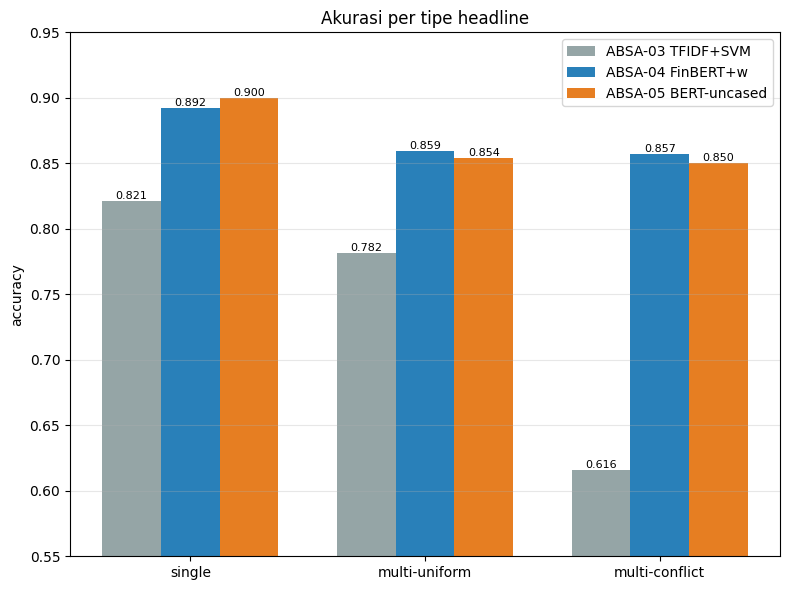

In [50]:
def head_type_acc(y_pred):
    te = absa_test.copy()
    te['pred'] = y_pred
    te['correct'] = te['pred'] == te['label']
    g  = te.groupby('s_no')
    ne = g['entity'].transform('size')
    ns = g['sentiment'].transform('nunique')
    te['head_type'] = np.where(ne == 1, 'single',
                       np.where(ns > 1, 'multi-conflict', 'multi-uniform'))
    return te.groupby('head_type')['correct'].mean()

acc_svm = head_type_acc(y_svm)
acc_04  = head_type_acc(y_04)
acc_05  = head_type_acc(y_05)

cmp = pd.DataFrame({'ABSA-03 SVM': acc_svm, 'ABSA-04': acc_04, 'ABSA-05': acc_05}).round(4)
cmp.loc['GAP (single − conflict)'] = [
    acc_svm['single'] - acc_svm['multi-conflict'],
    acc_04['single']  - acc_04['multi-conflict'],
    acc_05['single']  - acc_05['multi-conflict'],
]
print(cmp.round(4).to_string())

order = ['single', 'multi-uniform', 'multi-conflict']
x, w = np.arange(3), 0.25
fig, ax = plt.subplots(figsize=(8, 6))
b0 = ax.bar(x - w, [acc_svm[o] for o in order], w, label='ABSA-03 TFIDF+SVM', color='#95a5a6')
b1 = ax.bar(x,     [acc_04[o]  for o in order], w, label='ABSA-04 FinBERT+w', color='#2980b9')
b2 = ax.bar(x + w, [acc_05[o]  for o in order], w, label='ABSA-05 BERT-uncased', color='#e67e22')
for b in (b0, b1, b2):
    ax.bar_label(b, fmt='%.3f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel('accuracy'); ax.set_ylim(0.55, 0.95)
ax.set_title('Akurasi per tipe headline')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Kecepatan Inferensi

Latensi per sampel (batch=1, skenario serving real-time).

- Kedua BERT (~110M param) seharusnya setara — itu sanity check.
- Yang menarik adalah **baseline vs BERT**: SVM dan CRF jalan di CPU murni dan
  diharapkan jauh lebih cepat. Ini sisi trade-off yang dibayar untuk akurasi transformer —
  relevan jika pipeline harus jalan di mesin tanpa GPU.

In [51]:
def bench_absa_bert(model, tokenizer, df, n=200):
    sub = df.head(n)
    for _, r in sub.head(10).iterrows():   # warm-up
        enc = tokenizer(r['title'], r['entity'], return_tensors='pt',
                        truncation=True, max_length=128).to(DEVICE)
        with torch.no_grad(): model(**enc)
    if DEVICE == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _, r in sub.iterrows():
        enc = tokenizer(r['title'], r['entity'], return_tensors='pt',
                        truncation=True, max_length=128).to(DEVICE)
        with torch.no_grad(): model(**enc)
    if DEVICE == 'cuda': torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n * 1000

def bench_absa_svm(df, n=200):
    sub = df.head(n)
    t0 = time.perf_counter()
    for _, r in sub.iterrows():
        svm.predict(vectorizer.transform([r['title'] + ' [SEP] ' + r['entity']]))
    return (time.perf_counter() - t0) / n * 1000

def bench_ner_crf(sentences, n=200):
    sub = sentences[:n]
    t0 = time.perf_counter()
    for s in sub:
        crf.predict([sent2features(s)])
    return (time.perf_counter() - t0) / n * 1000

ms_svm = bench_absa_svm(absa_test)
ms_04  = bench_absa_bert(absa04, absa04_tok, absa_test)
ms_05  = bench_absa_bert(absa05, absa05_tok, absa_test)
ms_crf = bench_ner_crf(test_sents)

print(f'ABSA-03 SVM (CPU)        : {ms_svm:6.2f} ms/pair  ({1000/ms_svm:6.0f} pair/s)')
print(f'ABSA-04 FinBERT ({DEVICE.upper():4s})   : {ms_04:6.2f} ms/pair  ({1000/ms_04:6.0f} pair/s)')
print(f'ABSA-05 BERT ({DEVICE.upper():4s})      : {ms_05:6.2f} ms/pair  ({1000/ms_05:6.0f} pair/s)')
print(f'NER-03  CRF (CPU)        : {ms_crf:6.2f} ms/headline')
print(f'\nSVM {ms_04/ms_svm:.0f}× lebih cepat dari FinBERT (per-sample, tanpa batching)')

ABSA-03 SVM (CPU)        :   0.48 ms/pair  (  2067 pair/s)
ABSA-04 FinBERT (CUDA)   :   3.96 ms/pair  (   253 pair/s)
ABSA-05 BERT (CUDA)      :   4.01 ms/pair  (   249 pair/s)
NER-03  CRF (CPU)        :   0.04 ms/headline

SVM 8× lebih cepat dari FinBERT (per-sample, tanpa batching)


## 6. Agreement & Kalibrasi Confidence

- **Agreement**: seberapa sering kedua model memberi prediksi sama, dan siapa yang  
  benar saat mereka berbeda pendapat (tabel kontingensi ala McNemar).
- **Kalibrasi**: model yang baik harus lebih percaya diri saat benar daripada saat salah.  
  Gap confidence besar = sinyal confidencenya informatif untuk thresholding di produksi.

In [52]:
correct_04 = y_04 == y_true
correct_05 = y_05 == y_true

print(f'Agreement prediksi: {(y_04 == y_05).mean():.1%}\n')
print('Tabel kontingensi (jumlah pasangan):')
print(f'  Keduanya benar : {int((correct_04 & correct_05).sum())}')
print(f'  Hanya 04 benar : {int((correct_04 & ~correct_05).sum())}')
print(f'  Hanya 05 benar : {int((~correct_04 & correct_05).sum())}')
print(f'  Keduanya salah : {int((~correct_04 & ~correct_05).sum())}')

# Kalibrasi: rata-rata confidence saat benar vs salah
conf_04, conf_05 = probs_04.max(1), probs_05.max(1)
print('\nKalibrasi confidence (mean):')
print(f'  ABSA-04: benar={conf_04[correct_04].mean():.4f}  salah={conf_04[~correct_04].mean():.4f}',
      f' gap={conf_04[correct_04].mean() - conf_04[~correct_04].mean():.4f}')
print(f'  ABSA-05: benar={conf_05[correct_05].mean():.4f}  salah={conf_05[~correct_05].mean():.4f}',
      f' gap={conf_05[correct_05].mean() - conf_05[~correct_05].mean():.4f}')

Agreement prediksi: 92.9%

Tabel kontingensi (jumlah pasangan):
  Keduanya benar : 1223
  Hanya 04 benar : 46
  Hanya 05 benar : 48
  Keduanya salah : 131

Kalibrasi confidence (mean):
  ABSA-04: benar=0.9839  salah=0.9156  gap=0.0683
  ABSA-05: benar=0.9705  salah=0.8729  gap=0.0976


In [53]:
# Contoh kasus di mana kedua model berbeda pendapat
id2name = {0: 'neg', 1: 'neu', 2: 'pos'}
diff = absa_test[(y_04 != y_05)].copy()
diff['pred_04'] = [id2name[p] for p in y_04[y_04 != y_05]]
diff['pred_05'] = [id2name[p] for p in y_05[y_04 != y_05]]
diff['gold']    = diff['label'].map(id2name)

print(f'Total disagreement: {len(diff)} dari {len(absa_test)} pairs\n')
print(diff[['title', 'entity', 'gold', 'pred_04', 'pred_05']].head(10).to_string(index=False))

Total disagreement: 103 dari 1448 pairs

                                                                  title                 entity gold pred_04 pred_05
                                                 Catch the glow of gold                   gold  neu     pos     neu
                          GMR, investors rework their investment in GEL                    GMR  neu     neu     pos
                                    Dollar moves narrowly in Asia trade                 Dollar  neu     pos     neu
             Financial Technologies investors have a tough call to make Financial Technologies  neu     neu     neg
        Domestic companies turn back on bank loans, issue bonds instead     Domestic companies  neu     neu     neg
     Piramal Healthcare is in a range: Kunal Saraogi, Technical Analyst     Piramal Healthcare  neu     neu     pos
        Wall Street struggles to comply with new US sanctions on Russia            Wall Street  neu     neu     neg
Expect Moil cash reserves to ma

## 7. Ringkasan & Kesimpulan

| Aspek | BASELINE (CRF + SVM)  | FinBERT+w | BERT-uncased | Model yang lebih baik |
|---|---|---|---|---|
| Ukuran disk | **~1.3 MB** | ~419 MB | ~418 MB | **BASELINE** (320× lebih kecil) |
| Kecepatan (CPU-friendly) | **cepat** | butuh GPU | butuh GPU | **BASELINE** |
| NER entity-F1 | 0.8365 (CRF) | 0.9148 | 0.9163 | 04/05 (+0.08) |
| ABSA macro-F1 | 0.7669 | 0.8781 | 0.8785 | 04/05 (+0.11) |
| F1 kelas negative (minoritas) | rendah | **0.8892** | 0.8825 | **FINBERT** |
| Akurasi multi-conflict | 0.6156 | **0.8571** | 0.8503 | **FINBERT** |
| Gap single vs conflict | 0.2057 | **0.0349** | 0.0494 | **FINBERT** |

### Interpretasi

1. Baseline kalah telak di metrik kunci, bukan di metrik agregat. 
   Macro-F1 SVM (0.7669) 0.11 di bawah BERT, tapi di multi-conflict bedanya 0.24 absolut
   (0.6156 vs 0.8571). BoW runtuh persis di kasus yang memotivasi proyek ini, karena
   fitur title-nya identik untuk semua entitas dalam satu headline.
2. Baseline tetap menang di ukuran dan deployment: 
   1.3 MB vs 419 MB ( sekitar 320×), CPU murni vs butuh GPU. Untuk use case yang hanya butuh sentimen headline single-entity, SVM masih pilihan rasional.
3. FinBERT vs BERT_Cased hampir seri di macro-F1:
   pre-training finansial FinBERT tidak memberi keunggulan agregat. Keunggulan 04 di kelas negative dan multi-conflict berasal dari class weights, terbukti di notebook 07: BERT-uncased + weights +
   oversample (C1) justru mencapai gap terkecil (0.0153).
4. Untuk pipeline produksi:
   di antara FinBERT/BERT_Cased, kandidat final terbaik adalah absa_bert_oversample_final dari notebook 07 (gap 0.0153, macro-F1 0.8771).